# 05 - Generacion condicional ASL

Este notebook entrena la parte inversa del proyecto: en lugar de predecir una clase desde una imagen (`Imagen -> Clase`), aprende a sintetizar una imagen condicionada por una etiqueta (`Clase -> Imagen`).

La implementacion usa una cGAN ligera, adecuada para imagenes ASL de `64x64` o `128x128`. El generador recibe ruido latente y un embedding de clase; el discriminador recibe la imagen junto con la condicion de clase. Al final se prueba el motor de secuenciacion que convierte una frase en un GIF de signos.

## 1. Preparacion del entorno

In [9]:
from __future__ import annotations

import copy
import sys
from pathlib import Path
from pprint import pprint

from IPython.display import Image as IPyImage, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import load_yaml_config
from src.utils.reproducibility import set_global_seed

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\torre\Desktop\Big Data\ADNE\signlanguage-classifier


## 2. Carga y lectura de la configuracion

`configs/generation.yaml` concentra los hiperparametros del pipeline generativo: dimensiones latentes, embeddings de clase, resolucion de imagen, learning rates, tracking en W&B y rutas de salida.

In [10]:
CONFIG_PATH = PROJECT_ROOT / "configs" / "generation.yaml"
config = load_yaml_config(CONFIG_PATH)
set_global_seed(int(config.get("seed", 42)))

pprint(config)

{'data': {'batch_size': 64,
          'image_size': 64,
          'num_workers': 0,
          'root_dir': 'data/asl_alphabet_v1/processed',
          'train_subdir': 'train',
          'val_subdir': 'val'},
 'device': 'auto',
 'experiment_name': 'conditional_gan',
 'metrics': {'batch_size': 32,
             'compute_fid': True,
             'compute_inception_score': True,
             'enabled': False,
             'interval': 5,
             'num_samples': 512},
 'model': {'discriminator_channels': [128, 256, 512, 1024],
           'embedding_dim': 128,
           'generator_channels': [1024, 512, 256, 128],
           'image_channels': 3,
           'label_smoothing': 0.9,
           'latent_dim': 128},
 'output': {'artifacts_dir': 'artifacts/generation',
            'checkpoint_name': 'conditional_gan.pt',
            'samples_dir': 'samples'},
 'seed': 42,
 'tracking': {'project': 'image-generation',
              'run_name': 'conditional-gan-asl',
              'tags': ['generati

**Puntos importantes de la configuración:**

* **Arquitectura Densa**: `generator_channels` y `discriminator_channels` aumentados (hasta 1024 filtros) para capturar mejor los detalles de los dedos.
* **`data.image_size`**: Resolución en `64`. Equilibrio óptimo entre detalle morfológico y velocidad de entrenamiento.
* **`model.embedding_dim`**: Incrementado a `128` para mejorar la separación visual entre letras similares (A, S, M, etc.).

## 3. Comprobacion del dataset

Antes de entrenar, comprobamos que el dataset procesado existe, que sigue la estructura `ImageFolder` generada por `scripts/prepare_dataset.py` y que contiene las clases esperadas: `A-Z`, `delete`, `nothing`, `space`.

In [11]:
from torchvision.utils import make_grid

from src.models.generative_models import DEFAULT_ASL_CLASSES, denormalize_generated_images
from src.training.gan_trainer import build_generation_dataloader

dataset, loader = build_generation_dataloader(config)
expected_classes = set(DEFAULT_ASL_CLASSES)
found_classes = set(dataset.classes)

print(f"Numero de imagenes de entrenamiento: {len(dataset):,}")
print(f"Numero de clases: {len(dataset.classes)}")
print(dataset.classes)

missing = sorted(expected_classes - found_classes)
extra = sorted(found_classes - expected_classes)
print(f"Clases esperadas no encontradas: {missing or 'ninguna'}")
print(f"Clases extra: {extra or 'ninguna'}")

assert not missing, "Faltan clases ASL esperadas en el dataset procesado."
assert len(dataset.classes) == 29, "El pipeline generativo espera 29 clases ASL."

Numero de imagenes de entrenamiento: 73,950
Numero de clases: 29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'delete', 'nothing', 'space']
Clases esperadas no encontradas: ninguna
Clases extra: ninguna


Visualizamos un lote real ya transformado a la resolucion de entrenamiento. Esto ayuda a detectar rutas mal configuradas, clases mezcladas o transformaciones inesperadas antes de gastar tiempo en el entrenamiento.

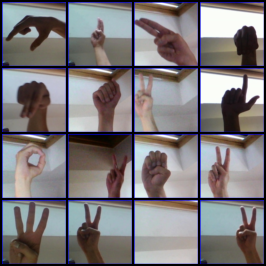

['Q', 'U', 'H', 'M', 'N', 'A', 'V', 'L', 'O', 'K', 'E', 'K', 'W', 'V', 'nothing', 'V']


In [12]:
real_images, real_labels = next(iter(loader))
preview_count = min(16, real_images.size(0))
grid = make_grid(denormalize_generated_images(real_images[:preview_count]), nrow=4, padding=2)
preview_path = PROJECT_ROOT / "artifacts" / "generation" / "real_batch_preview.png"
preview_path.parent.mkdir(parents=True, exist_ok=True)

from torchvision.utils import save_image

save_image(grid, preview_path)
display(IPyImage(filename=str(preview_path)))
print([dataset.classes[int(label)] for label in real_labels[:preview_count]])

## 4. Overrides opcionales para pruebas

Por defecto se entrena con los valores del YAML. Para validar que todo arranca sin esperar un entrenamiento completo, activa `QUICK_RUN = True`. Para usar W&B, deja `DISABLE_WANDB = False` y asegurate de tener `WANDB_API_KEY` en `.env`.

In [ ]:
train_config = copy.deepcopy(config)

QUICK_RUN = False # Cambia a True para pruebas rápidas (menos épocas, checkpoints más frecuentes)
DISABLE_WANDB = False # Cambia a True para desactivar el seguimiento con Weights & Biases (más rápido pero sin visualización de métricas en tiempo real)
ENABLE_GENERATIVE_METRICS = True # Cambia a False para desactivar métricas como FID durante el entrenamiento (más rápido pero sin métricas)

if QUICK_RUN:
    train_config["training"]["epochs"] = 2
    train_config["training"]["checkpoint_interval"] = 1
    train_config["training"]["sample_interval"] = 1

if DISABLE_WANDB:
    train_config["tracking"]["use_wandb"] = False

train_config["metrics"]["enabled"] = ENABLE_GENERATIVE_METRICS

pprint(train_config)

{'data': {'batch_size': 64,
          'image_size': 64,
          'num_workers': 0,
          'root_dir': 'data/asl_alphabet_v1/processed',
          'train_subdir': 'train',
          'val_subdir': 'val'},
 'device': 'auto',
 'experiment_name': 'conditional_gan',
 'metrics': {'batch_size': 32,
             'compute_fid': True,
             'compute_inception_score': True,
             'enabled': True,
             'interval': 5,
             'num_samples': 512},
 'model': {'discriminator_channels': [128, 256, 512, 1024],
           'embedding_dim': 128,
           'generator_channels': [1024, 512, 256, 128],
           'image_channels': 3,
           'label_smoothing': 0.9,
           'latent_dim': 128},
 'output': {'artifacts_dir': 'artifacts/generation',
            'checkpoint_name': 'conditional_gan.pt',
            'samples_dir': 'samples'},
 'seed': 42,
 'tracking': {'project': 'image-generation',
              'run_name': 'conditional-gan-asl',
              'tags': ['generatio

## 5. Entrenamiento de la cGAN

Esta celda ejecuta el trainer reusable de `src/training/gan_trainer.py`. Durante el entrenamiento se guardan:

- `artifacts/generation/conditional_gan.pt`: checkpoint final autocontenible.
- `artifacts/generation/conditional_gan_epoch_XXXX.pt`: checkpoints periodicos.
- `artifacts/generation/samples/epoch_XXXX.png`: cuadriculas generadas con fixed noise.
- En W&B: losses, muestras generadas y, si lo activas, Inception Score/FID.

In [14]:
from src.training.gan_trainer import train_conditional_gan

checkpoint_path = train_conditional_gan(train_config)
print(f"Checkpoint final: {checkpoint_path}")

discriminator_loss,█▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
fid,▇▆▁█▇▆▅▃▃▅
generator_loss,▁▁▂▃▃▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▆▇▇▇▇▇▇▇▇▇████
inception_score,▃▁▁▃▄▂▇█▅▆
discriminator_loss,0.18619
epoch,50
fid,235.68227
generator_loss,6.04335
inception_score,2.36157


Checkpoint final: C:\Users\torre\Desktop\Big Data\ADNE\signlanguage-classifier\artifacts\generation\conditional_gan.pt


## 6. Inspeccion visual de muestras generadas

Mostrando: c:\Users\torre\Desktop\Big Data\ADNE\signlanguage-classifier\artifacts\generation\samples\epoch_0050.png


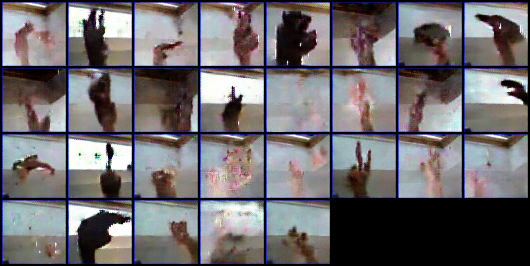

In [15]:
samples_dir = PROJECT_ROOT / train_config["output"]["artifacts_dir"] / train_config["output"]["samples_dir"]
sample_files = sorted(samples_dir.glob("*.png"))

if not sample_files:
    print(f"No hay muestras todavia en {samples_dir}. Ejecuta primero la celda de entrenamiento.")
else:
    latest_sample = sample_files[-1]
    print(f"Mostrando: {latest_sample}")
    display(IPyImage(filename=str(latest_sample)))

> Tras analizar los resultados se observa que el modelo muestra un comportamiento mixto. Aunque las imágenes todavía presentan un aspecto algo borroso, ya es posible identificar siluetas que se aproximan razonablemente a la morfología de una mano humana y a las posiciones esperadas del alfabeto ASL. Sin embargo, la consistencia no es uniforme: mientras que en algunas muestras se percibe claramente la estructura de los dedos, en otras los resultados son todavía muy inestables, manifestándose como nubes de puntos o manchas abstractas que no guardan relación con la anatomía real. En definitiva, el modelo ha superado la fase de ruido aleatorio inicial y empieza a dibujar formas reconocibles, pero se encuentra en un punto intermedio donde todavía conviven aciertos visuales con fallos estructurales importantes.

## 7. Prueba del motor frase -> GIF

`generate_phrase_sequence()` tokeniza la frase caracter a caracter, ignora simbolos no soportados y convierte espacios en la clase `space`. Si existe un checkpoint entrenado, genera cada frame con la cGAN; si no, usa imagenes del dataset como fallback para que Streamlit siga siendo usable.

Labels: ['H', 'A', 'L', 'A']
Skipped: []
Source: model


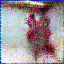

In [16]:
from src.inference.generator import generate_phrase_sequence, resolve_default_generator_checkpoint

resolved_checkpoint = checkpoint_path if "checkpoint_path" in globals() else resolve_default_generator_checkpoint()
sequence = generate_phrase_sequence(
    phrase="hala",
    frame_duration=1,
    checkpoint_path=resolved_checkpoint,
)

print("Labels:", sequence.labels)
print("Skipped:", sequence.skipped_characters)
print("Source:", sequence.source)
display(IPyImage(data=sequence.gif_bytes, format="gif"))

## 8. Conexion con Streamlit

La app busca automaticamente `artifacts/generation/conditional_gan.pt`. Una vez entrenado el modelo, lanza:

```bash
streamlit run app/streamlit_app.py
```

En el modo `Generacion`, escribe una frase, selecciona la duracion de frame entre `0.5s` y `2.0s`, visualiza el GIF y descargalo.